# Lab-03 - Gear-tooth Inspection
    In industrial machine vision, how a watch gear could be inspected to check whether it had any missing or broken
    teeth. The inspection gear-tooth has maximum measurement of 7 mm and minimum defect size of 0.005 mm
    should be detected. Tolerance and margin will be fixed for 1 mm. The aspect ratio of the camera be 4:3. 

# 1. Determine the camera resolution and FOV.
    Camera should have enough resolution to
    have at least 3 pixels for minimum defect size.


# 2. Find the location of missing or broken teeth by using OpenCV.


In [1]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt

## Step-1 : Preprocessing

In [2]:
img = cv2.imread('source/case3.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [3]:
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
_, thresh = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

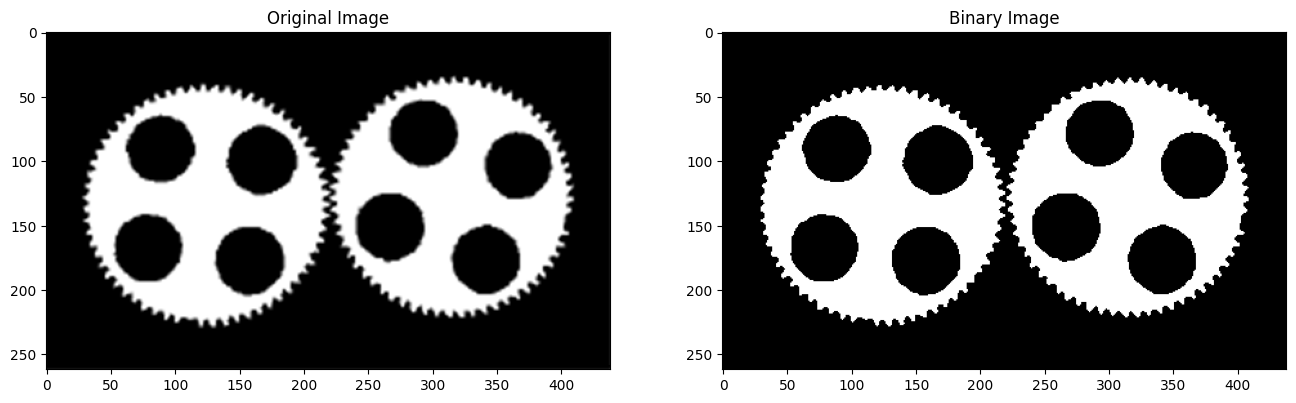

In [4]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.title('Binary Image')
plt.imshow(thresh, cmap='gray')
plt.show()

## Step-2 : Calibate a parameter for get every gear tooth.

In [5]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
output = img.copy()

In [ ]:
for gear_index, cnt in enumerate(contours):
    if cv2.contourArea(cnt) < 1000:
        continue
        
    # Find the exact center of the gear
    M = cv2.moments(cnt)
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    
    # Draw a green dot in the center
    cv2.circle(output, (cx, cy), 2, (0, 255, 0), -1) 
    
    # Calculate the distance from the center to every pixel on the edge
    points = cnt[:, 0, :]
    n_points = len(points)
    distances = np.sqrt((points[:, 0] - cx)**2 + (points[:, 1] - cy)**2)
    
    # Smooth the distances to ignore the jagged, bad-quality pixels
    smoothed_dist = np.zeros(n_points)
    for i in range(n_points):
        # Average the distance over a small 5-pixel window
        window = [distances[(i + j) % n_points] for j in range(-2, 3)]
        smoothed_dist[i] = sum(window) / 5.0
        
    # Find the local peaks (The tooth tips)
    peaks = []
    
    for i in range(n_points):
        # Look at a 15-pixel window around the current point
        window_size = 6
        neighborhood = [smoothed_dist[(i + j) % n_points] for j in range(-window_size, window_size + 1)]
        
        # If this point is further from the center than its neighbors, it's a tooth tip
        if smoothed_dist[i] == max(neighborhood):
            
            # Make sure we don't count a flat tip twice
            is_duplicate = False
            for p in peaks:
                # Check the shortest distance around the circle to the last peak
                dist_to_p = min(abs(i - p), n_points - abs(i - p))
                if dist_to_p < 9:  # Minimum pixel distance between two separate teeth
                    is_duplicate = True
                    break
                    
            if not is_duplicate:
                peaks.append(i)
                
    # Draw the results
    for p in peaks:
        tooth_tip = tuple(points[p])
        cv2.circle(output, tooth_tip, 1, (255, 0, 0), -1)
        
    print(f"Gear {gear_index + 1}: Mapped {len(peaks)} teeth using radial distance.")

Gear 1: Mapped 62 teeth using radial distance.
Gear 2: Mapped 62 teeth using radial distance.


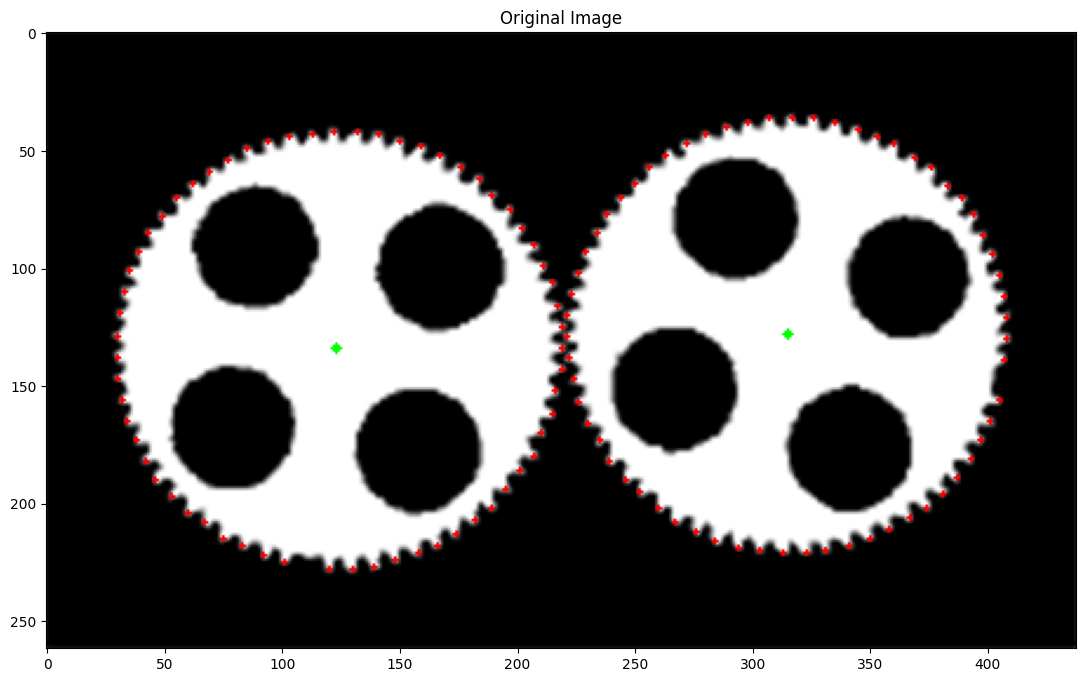

In [7]:
plt.figure(figsize=(40, 8))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(output, cmap='gray')
plt.show()

## Step-3 : Find missing tooth

In [8]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
output = img.copy()

In [9]:
for gear_index, cnt in enumerate(contours):
    if cv2.contourArea(cnt) < 1000:
        continue
        
    # Find the center of the gear
    M = cv2.moments(cnt)
    cx = int(M['m10'] / M['m00'])
    cy = int(M['m01'] / M['m00'])
    
    # Draw a small center dot for reference
    cv2.circle(output, (cx, cy), 3, (0, 255, 0), -1)
    
    points = cnt[:, 0, :]
    n_points = len(points)
    distances = np.sqrt((points[:, 0] - cx)**2 + (points[:, 1] - cy)**2)
    
    # Smooth the distances to ignore pixelation
    smoothed_dist = np.zeros(n_points)
    for i in range(n_points):
        window = [distances[(i + j) % n_points] for j in range(-2, 3)]
        smoothed_dist[i] = sum(window) / 5.0
        
    peaks = []
    
    # 1. FIND ALL TEETH
    for i in range(n_points):
        window_size = 6
        neighborhood = [smoothed_dist[(i + j) % n_points] for j in range(-window_size, window_size + 1)]
        
        if smoothed_dist[i] == max(neighborhood):
            is_duplicate = False
            for p in peaks:
                dist_to_p = min(abs(i - p), n_points - abs(i - p))
                if dist_to_p < 9:
                    is_duplicate = True
                    break
            if not is_duplicate:
                peaks.append(i)
                
    # 2. FIND THE MISSING TEETH AND CALCULATE ANGLE
    for i in range(len(peaks)):
        p1_idx = peaks[i]
        p2_idx = peaks[(i + 1) % len(peaks)]
        
        p1 = points[p1_idx]
        p2 = points[p2_idx]
        
        # Mark the existing teeth
        cv2.circle(output, tuple(p1), 2, (255, 0, 0), -1)
        
        gap_width = np.linalg.norm(p1 - p2)
        
        # If gap is wider than normal (missing tooth)
        if gap_width > 15:
            mid_x = int((p1[0] + p2[0]) / 2)
            mid_y = int((p1[1] + p2[1]) / 2)
            
            # --- ANGLE CALCULATION ---
            dx = mid_x - cx
            dy = mid_y - cy
            
            angle = math.degrees(math.atan2(dy, dx))
            angle = angle % 360  # Normalize to 0-360 range
            
            # --- DRAW THE CLOCK HANDS ---
            # Calculate a dynamic line length based on how far the defect is from center
            line_length = int(math.hypot(dx, dy))
            
            # Draw 0-degree reference line (Horizontal to the right)
            cv2.line(output, (cx, cy), (cx + line_length, cy), (255, 255, 0), 1) # Cyan
            
            # Draw line pointing to the defect
            cv2.line(output, (cx, cy), (mid_x, mid_y), (0, 255, 255), 1) # Yellow
            # -----------------------------
            
            # Draw a red dot and the degree text
            cv2.circle(output, (mid_x, mid_y), 2, (0, 0, 255), -1)
            cv2.putText(output, f"{angle:.1f} deg", (mid_x - 30, mid_y + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
            
            print(f"Gear {gear_index + 1}: Missing tooth found at {angle:.1f} degrees.")

Gear 1: Missing tooth found at 98.0 degrees.
Gear 2: Missing tooth found at 11.8 degrees.


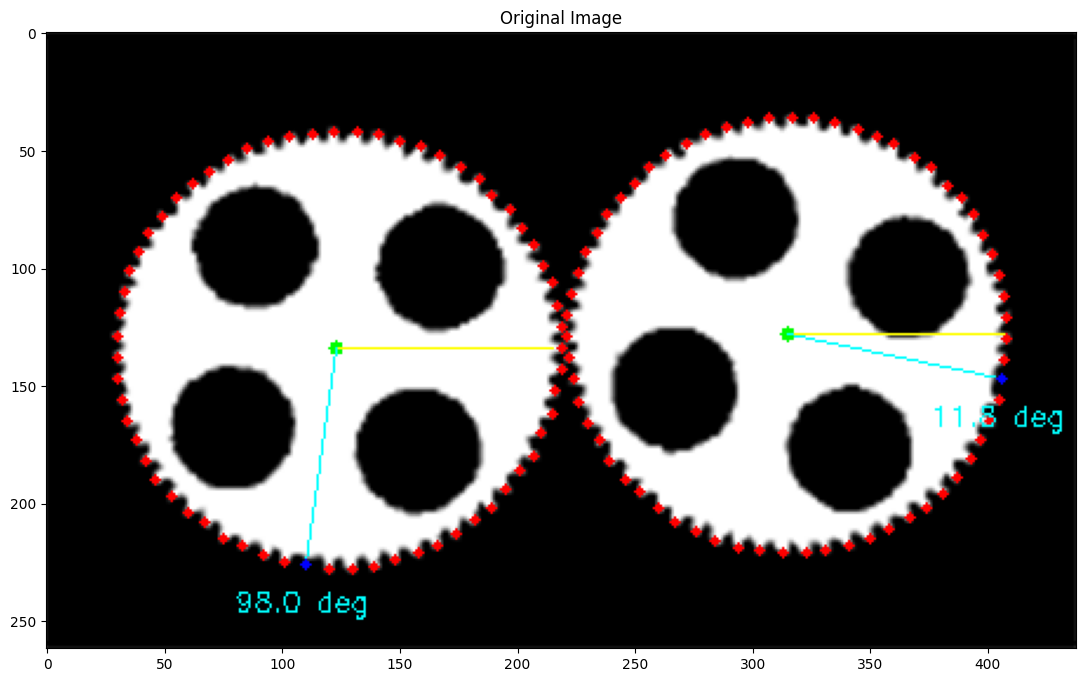

In [10]:
plt.figure(figsize=(40, 8))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(output, cmap='gray')
plt.show()